# Results from the ML model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import os

/home/matilde/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "
/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
def _compute_metrics(true, pred, label):
    rmse = np.sqrt(mean_squared_error(true, pred))
    mae  = mean_absolute_error(true, pred)
    r2   = r2_score(true, pred)
    print(f"Metrics for {label}:")
    print(f"    RMSE = {rmse:.4f} GeV")
    print(f"    MAE  = {mae:.4f} GeV")
    print(f"    R²   = {r2:.4f}")
    return rmse, mae, r2

In [3]:

def _scatter(x, y, label, color, xlabel, title):
    """
        Base scatter routine shared by scatter plot functions.
    """
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]

    plt.figure(figsize=(10, 8))
    plt.scatter(x, y, s=4, alpha=0.35, color=color, label=label, rasterized=True)

    lim_max = max(x.max(), y.max()) * 1.05
    lim = [0, lim_max]
    plt.plot(lim, lim, "k--", lw=1, label="y = x")

    plt.title(title, fontsize=13, fontweight="bold")
    plt.xlabel(xlabel, fontsize=11)
    plt.ylabel("GenMET_pt [GeV]", fontsize=11)
    plt.legend(markerscale=3, fontsize=9)
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
    return

In [4]:
def _plot_fold_learning_curves(df_folds, label):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"CV Fold Learning Curves — {label}", fontsize=13, fontweight="bold")
    colors = ["tab:blue", "tab:orange", "tab:green"]

    for fh in df_folds.groupby("fold"):
        fold_idx, df = fh
        c = colors[(fold_idx - 1) % len(colors)]
        axes[0].plot(df["epoch"], df["loss"],     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[0].plot(df["epoch"], df["val_loss"], color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")
        axes[1].plot(df["epoch"], df["loss"].pow(0.5),     color=c, lw=1.5, label=f"Train fold {fold_idx}")
        axes[1].plot(df["epoch"], df["val_loss"].pow(0.5), color=c, lw=1.5, linestyle="--", label=f"Val fold {fold_idx}")

    for ax, ylabel, title in zip(axes, ["MSE", "RMSE"], ["Loss (MSE)", "RMSE"]):
        ax.set_title(title, fontsize=11)
        ax.set_xlabel("Epoch", fontsize=10)
        ax.set_ylabel(ylabel, fontsize=10)
        ax.legend(fontsize=8)
        ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
    return

In [5]:
def _plot_learning_curves(df_lc, label):
    epochs  = range(1, len(df_lc) + 1)
    has_val = "val_loss" in df_lc.columns
    has_mse = "mse" in df_lc.columns

    fig, axes = plt.subplots(1, 2 if has_mse else 1, figsize=(14 if has_mse else 7, 5))
    if not has_mse:
        axes = [axes]
    fig.suptitle(f"Learning Curves — {label}", fontsize=13, fontweight="bold")

    # Loss
    axes[0].plot(epochs, df_lc["loss"], color="red", lw=1.5, label="Train loss")
    if has_val:
        axes[0].plot(epochs, df_lc["val_loss"], color="blue", lw=1.5, label="Val loss")
    axes[0].set_title("Loss (MSE)", fontsize=11)
    axes[0].set_xlabel("Epoch", fontsize=10)
    axes[0].set_ylabel("MSE", fontsize=10)
    axes[0].legend(fontsize=9)
    axes[0].grid(alpha=0.3)

    # RMSE
    if has_mse:
        axes[1].plot(epochs, df_lc["mse"].pow(0.5), color="red", lw=1.5, label="Train RMSE")
        if has_val:
            axes[1].plot(epochs, df_lc["val_mse"].pow(0.5), color="blue", lw=1.5, label="Val RMSE")
        axes[1].set_title("RMSE metric", fontsize=11)
        axes[1].set_xlabel("Epoch", fontsize=10)
        axes[1].set_ylabel("RMSE", fontsize=10)
        axes[1].legend(fontsize=9)
        axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Learning curves for {label}:")
    print(f"    Epochs run       : {len(df_lc)}")
    print(f"    Final train loss : {df_lc['loss'].iloc[-1]:.4f}")
    if has_val:
        print(f"    Final val loss   : {df_lc['val_loss'].iloc[-1]:.4f}")
        print(f"    Best val loss    : {df_lc['val_loss'].min():.4f}  "
              f"(epoch {df_lc['val_loss'].idxmin() + 1})")

In [6]:
def _plot_predicted_MET(df, label, color):
    """
        Scatter of predicted MET (x) vs true GenMET (y).
        Reads from the model output parquet: columns 'y_test_pred' and 'y_test'.
    """
    x = df["y_test_pred"]
    y = df["y_test"]

    print(f"Statistics for dataset {label}:")
    print(f"    Predicted MET:\n {x.describe()}")
    print(f"    Testing GenMET:\n {y.describe()}")

    _compute_metrics(y.to_numpy(), x.to_numpy(), label)

    _scatter(
        x=x, y=y,
        label=label,
        color=color,
        xlabel="Predicted MET_pt [GeV]",
        title=f"GenMET vs Predicted MET — {label}",
    )
    return

In [7]:
def _plot_true_MET(df_raw, label, color):
    """
        Scatter of raw reconstructed MET_pt (x) vs GenMET_pt (y).
        Reads from the original dataset parquet: columns 'MET_pt' and 'GenMET_pt'.
    """
    x = pd.Series(df_raw["MET_pt"])
    y = pd.Series(df_raw["GenMET_pt"])

    print(f"Statistics for dataset {label} (raw MET):")
    print(f"    Mean MET_pt   : {x.mean():.4f}   Median: {x.median():.4f}")
    print(f"    Mean GenMET_pt: {y.mean():.4f}   Median: {y.median():.4f}")

    _compute_metrics(y.to_numpy(), x.to_numpy(), label + " baseline")

    _scatter(
        x=x, y=y,
        label=label,
        color=color,
        xlabel="MET_pt [GeV]",
        title=f"GenMET vs MET — {label}",
    )
    return

---

## ZZTo2L2Nu

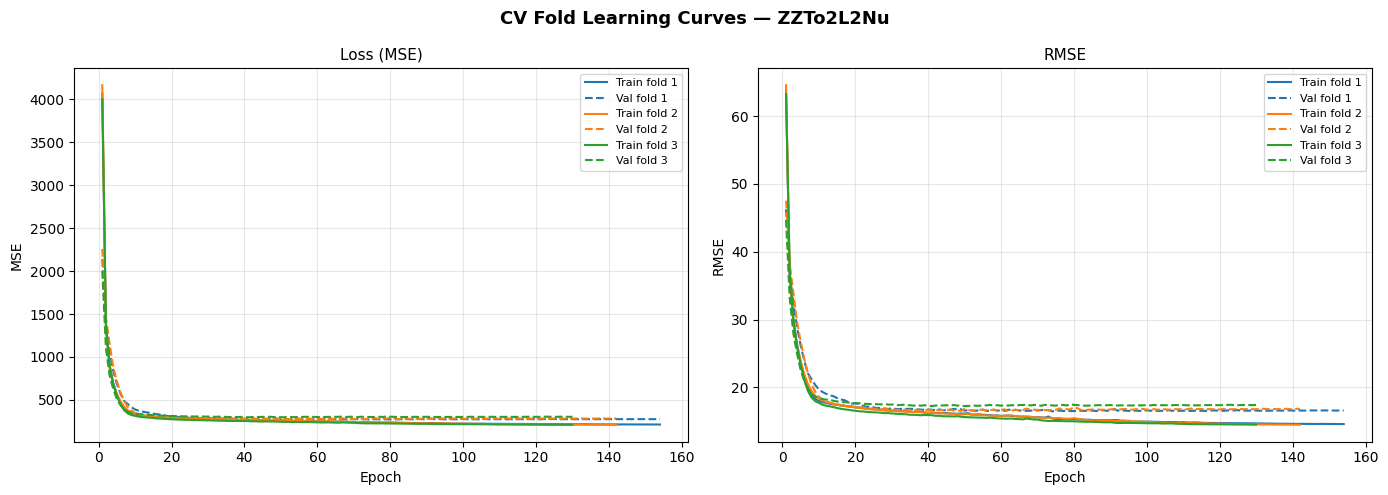

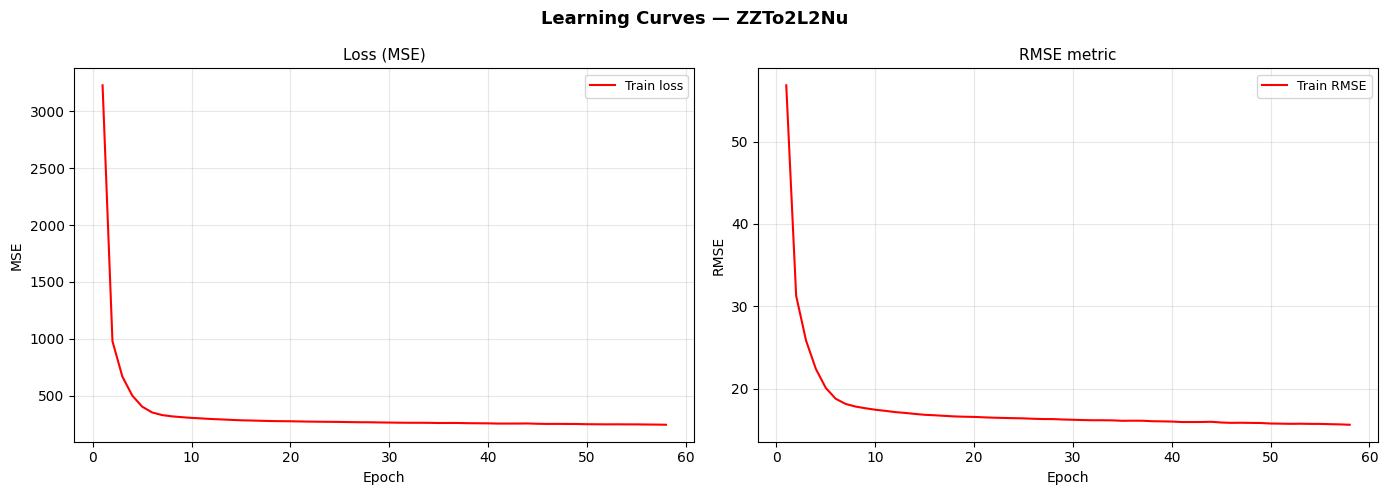

Learning curves for ZZTo2L2Nu:
    Epochs run       : 58
    Final train loss : 244.1705
Statistics for dataset ZZTo2L2Nu:
    Predicted MET:
 count    6065.000000
mean       58.259548
std        50.927162
min         3.934777
25%        28.174356
50%        43.541142
75%        71.058044
max      1336.543701
Name: y_test_pred, dtype: float64
    Testing GenMET:
 count    6065.000000
mean       58.183835
std        52.164684
min         0.447021
25%        25.578125
50%        44.656250
75%        73.375000
max       955.000000
Name: y_test, dtype: float64
Metrics for ZZTo2L2Nu:
    RMSE = 16.8372 GeV
    MAE  = 12.1641 GeV
    R²   = 0.8958


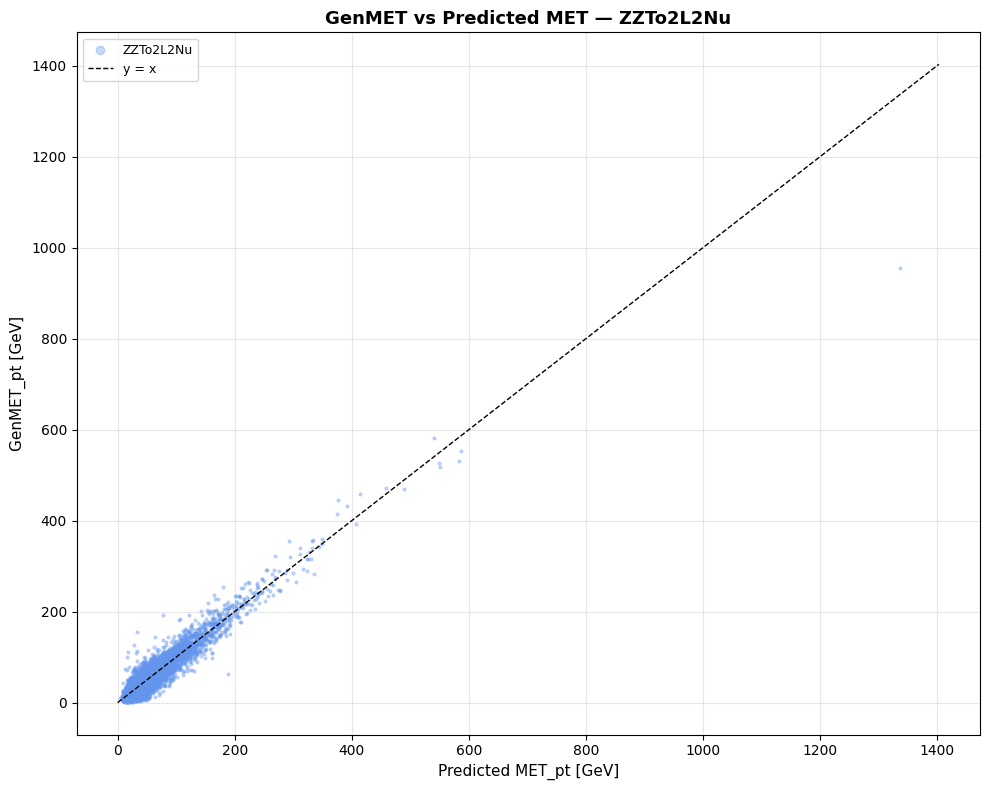

Statistics for dataset ZZTo2L2Nu (raw MET):
    Mean MET_pt   : 63.1834   Median: 50.6435
    Mean GenMET_pt: 57.5286   Median: 44.3750
Metrics for ZZTo2L2Nu baseline:
    RMSE = 20.1984 GeV
    MAE  = 15.3402 GeV
    R²   = 0.8411


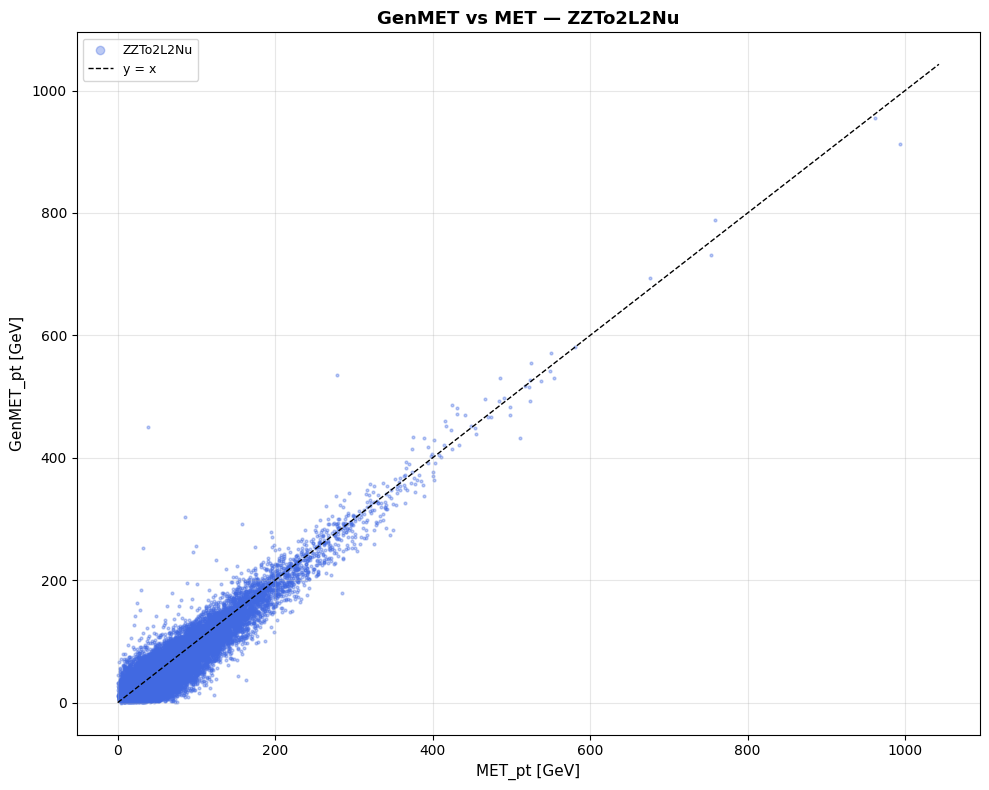

In [8]:
EVENT      = "ZZTo2L2Nu"
FOLD_LC_FILE = f"fold_histories_{EVENT}.parquet"
LC_FILE    = f"learning_curves_{EVENT}.parquet"
PRED_FILE  = f"METpred_vs_GenMET_{EVENT}.parquet"
RAW_FILE   = f"../CleanedDatasets/{EVENT}.parquet"

# Load fold learning curves (loss, val_loss, mse, val_mse)
df_folds = pd.read_parquet(FOLD_LC_FILE)

# Load learning curves (loss, val_loss, mse, val_mse)
df_lc = pd.read_parquet(LC_FILE)

# Load model predictions (y_test_pred, y_test)
df_pred = pd.read_parquet(PRED_FILE)

# Load original dataset (MET_pt, GenMET_pt)
df_raw = pd.read_parquet(RAW_FILE, columns=["MET_pt", "GenMET_pt"])

# Fold learning curves
_plot_fold_learning_curves(df_folds, label=EVENT)

# Learning curves
_plot_learning_curves(df_lc, label=EVENT)

# Predicted MET vs GenMET
_plot_predicted_MET(df_pred, label=EVENT, color="cornflowerblue")

# True reconstructed MET vs GenMET (baseline)
_plot_true_MET(df_raw, label=EVENT, color="royalblue")


---

## HToAATo2Mu2B

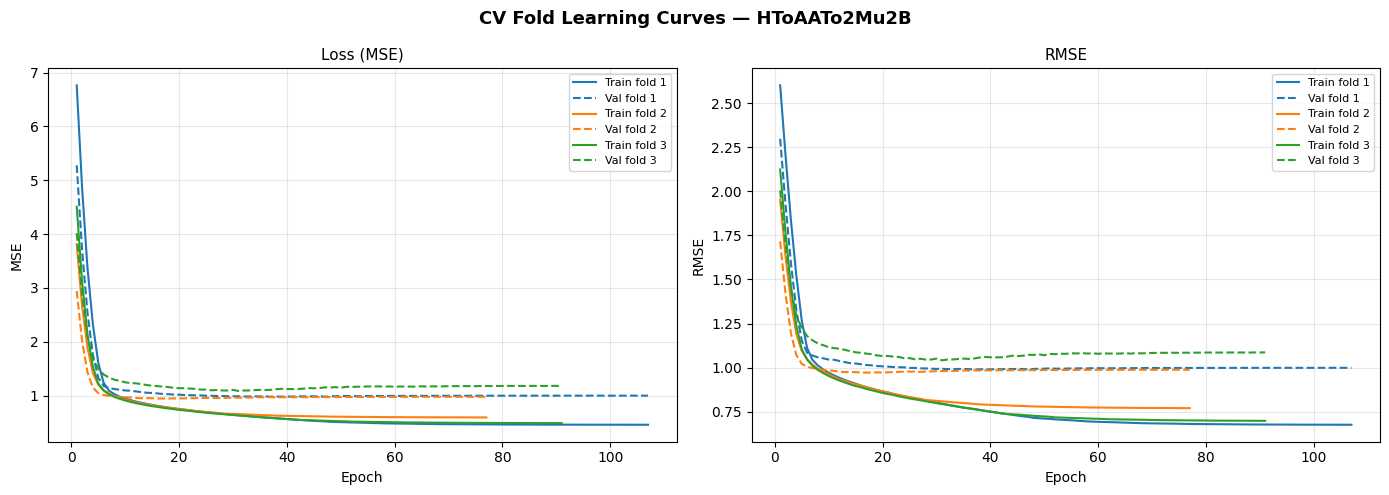

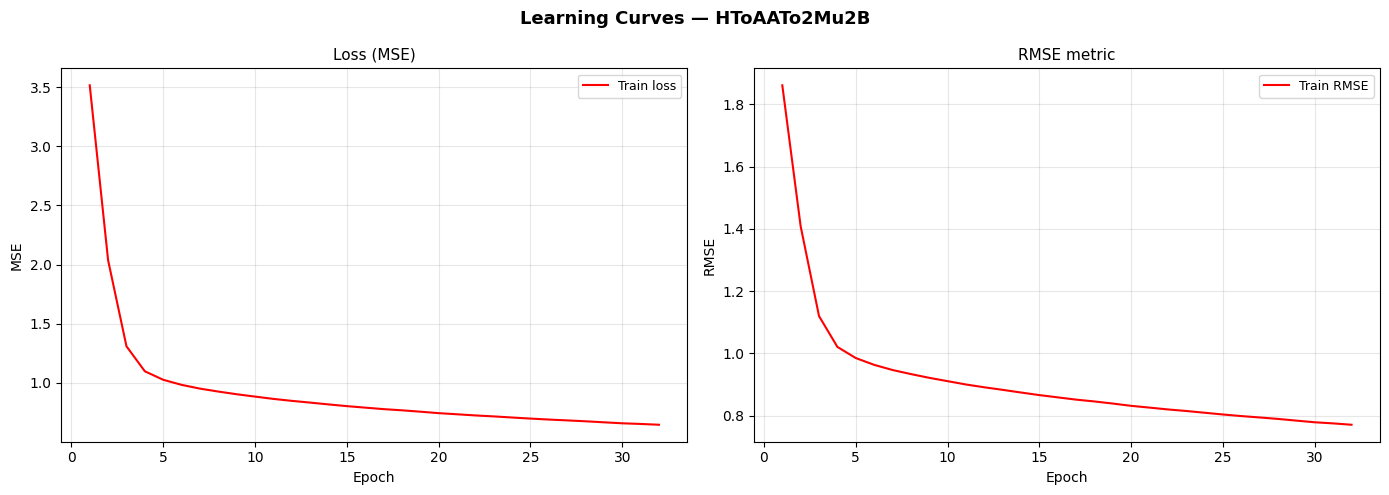

Learning curves for HToAATo2Mu2B:
    Epochs run       : 32
    Final train loss : 0.6448
Statistics for dataset HToAATo2Mu2B:
    Predicted MET:
 count    467.000000
mean       6.795216
std       15.200501
min        0.338296
25%        3.399527
50%        5.297959
75%        7.615836
max      318.983093
Name: y_test_pred, dtype: float64
    Testing GenMET:
 count    4.670000e+02
mean     7.676313e+00
std      9.544009e+00
min      2.030376e-12
25%      1.725586e+00
50%      5.445312e+00
75%      1.050781e+01
max      1.122500e+02
Name: y_test, dtype: float64
Metrics for HToAATo2Mu2B:
    RMSE = 17.4582 GeV
    MAE  = 6.1969 GeV
    R²   = -2.3533


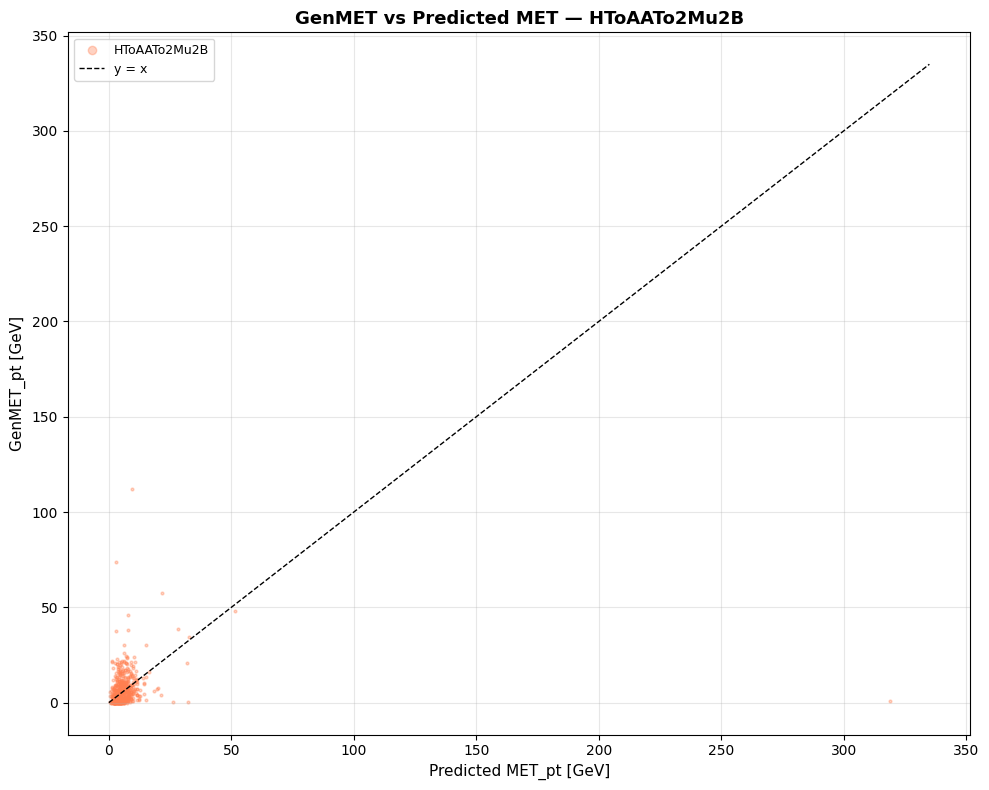

Statistics for dataset HToAATo2Mu2B (raw MET):
    Mean MET_pt   : 28.6858   Median: 25.2294
    Mean GenMET_pt: 8.4248   Median: 6.0137
Metrics for HToAATo2Mu2B baseline:
    RMSE = 27.0130 GeV
    MAE  = 21.4245 GeV
    R²   = -7.7996


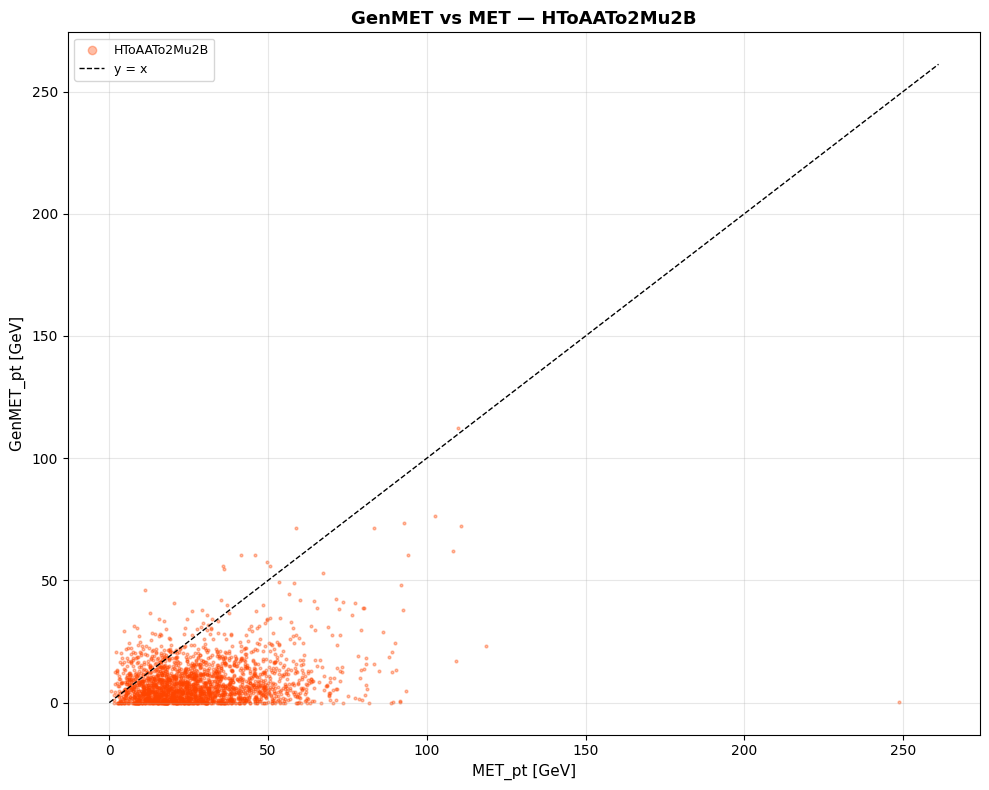

In [9]:
EVENT      = "HToAATo2Mu2B"
FOLD_LC_FILE = f"fold_histories_{EVENT}.parquet"
LC_FILE    = f"learning_curves_{EVENT}.parquet"
PRED_FILE  = f"METpred_vs_GenMET_{EVENT}.parquet"
RAW_FILE   = f"../CleanedDatasets/{EVENT}.parquet"

# Load fold learning curves (loss, val_loss, mse, val_mse)
df_folds = pd.read_parquet(FOLD_LC_FILE)

# Load learning curves (loss, val_loss, mse, val_mse)
df_lc = pd.read_parquet(LC_FILE)

# Load model predictions (y_test_pred, y_test)
df_pred = pd.read_parquet(PRED_FILE)

# Load original dataset (MET_pt, GenMET_pt)
df_raw = pd.read_parquet(RAW_FILE, columns=["MET_pt", "GenMET_pt"])

# Fold learning curves
_plot_fold_learning_curves(df_folds, label=EVENT)

# Learning curves
_plot_learning_curves(df_lc, label=EVENT)

# Predicted MET vs GenMET
_plot_predicted_MET(df_pred, label=EVENT, color="coral")

# True reconstructed MET vs GenMET (baseline)
_plot_true_MET(df_raw, label=EVENT, color="orangered")


---

HToAATo2Mu2B augmented dataset

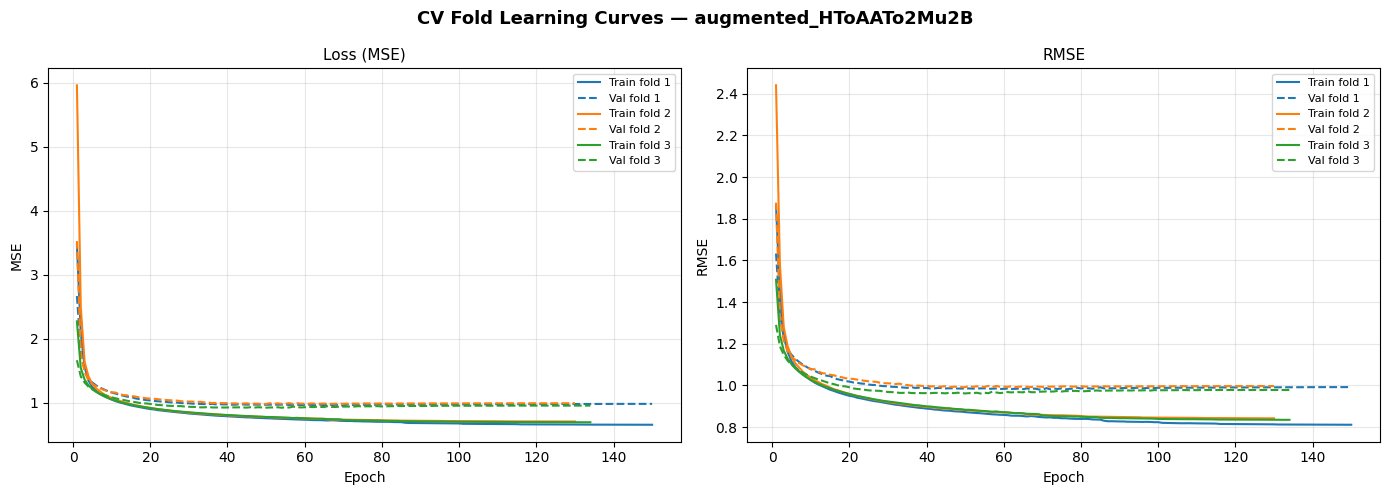

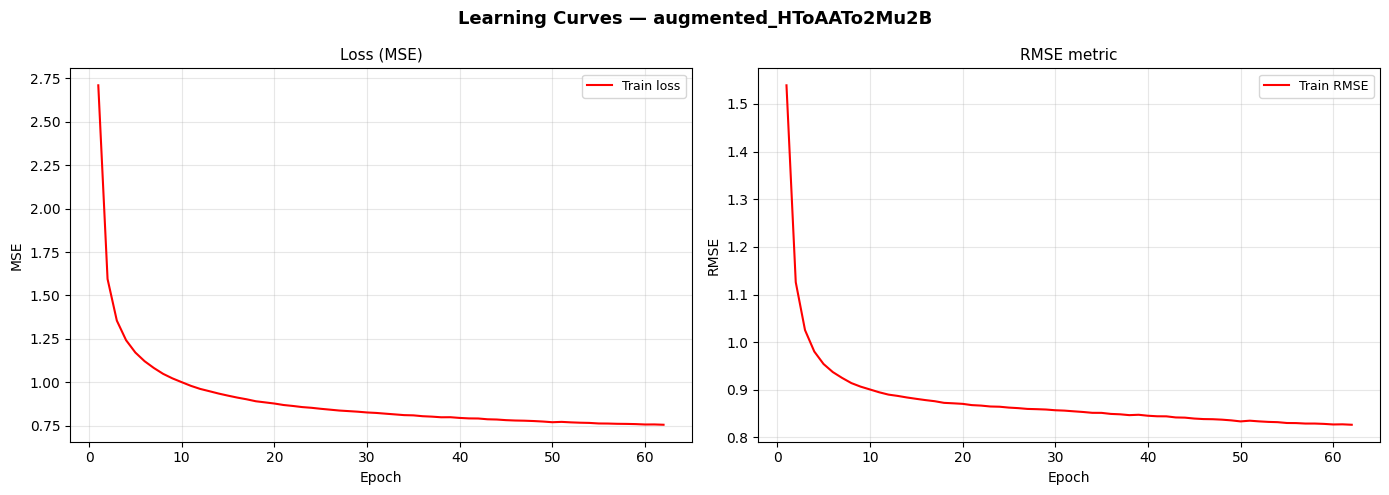

Learning curves for augmented_HToAATo2Mu2B:
    Epochs run       : 62
    Final train loss : 0.7556
Statistics for dataset augmented_HToAATo2Mu2B:
    Predicted MET:
 count    998.000000
mean       5.821292
std        7.673020
min        0.559291
25%        2.591545
50%        4.571332
75%        7.038637
max      169.112885
Name: y_test_pred, dtype: float64
    Testing GenMET:
 count    9.980000e+02
mean     7.874780e+00
std      1.139156e+01
min      4.285461e-13
25%      1.585205e+00
50%      5.089844e+00
75%      1.017383e+01
max      1.730000e+02
Name: y_test, dtype: float64
Metrics for augmented_HToAATo2Mu2B:
    RMSE = 9.5094 GeV
    MAE  = 5.3376 GeV
    R²   = 0.3025


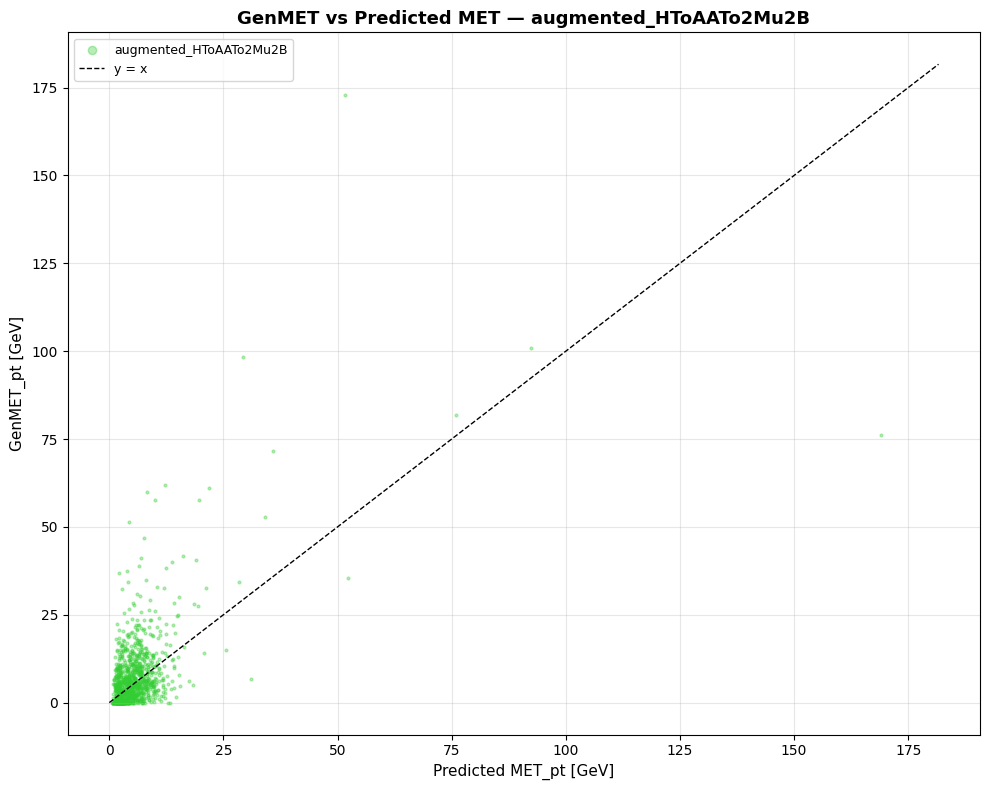

Statistics for dataset augmented_HToAATo2Mu2B (raw MET):
    Mean MET_pt   : 28.0283   Median: 24.7437
    Mean GenMET_pt: 7.6310   Median: 5.0820
Metrics for augmented_HToAATo2Mu2B baseline:
    RMSE = 26.8051 GeV
    MAE  = 21.4961 GeV
    R²   = -7.3550


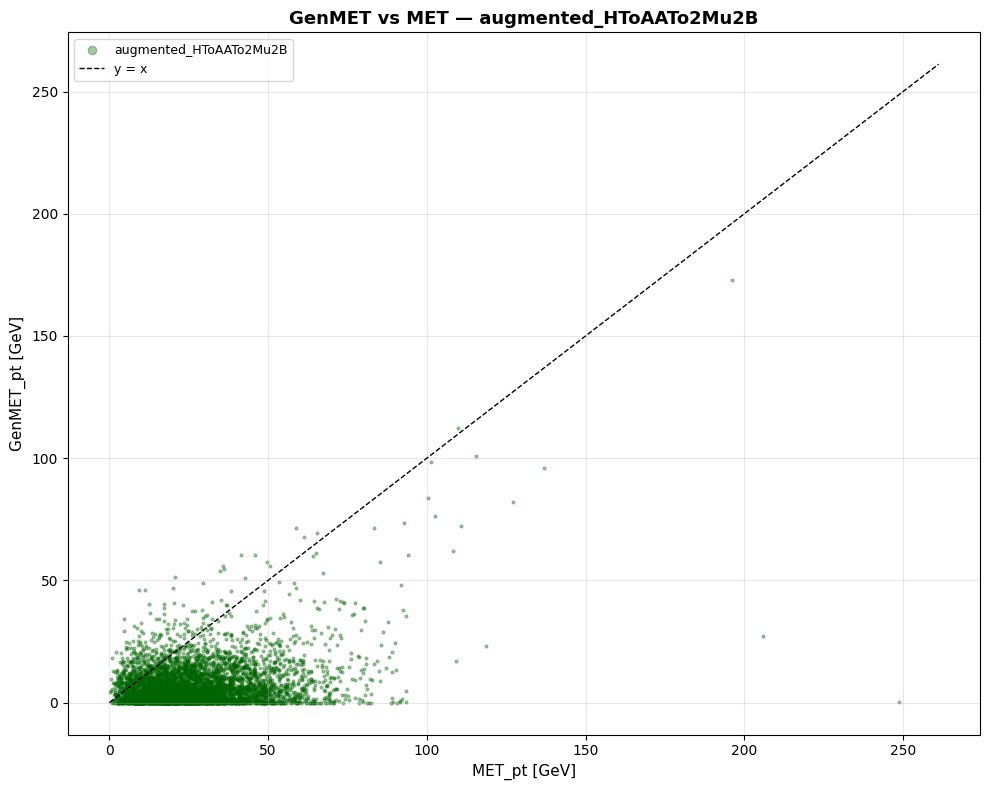

In [10]:
EVENT      = "augmented_HToAATo2Mu2B"
FOLD_LC_FILE = f"fold_histories_{EVENT}.parquet"
LC_FILE    = f"learning_curves_{EVENT}.parquet"
PRED_FILE  = f"METpred_vs_GenMET_{EVENT}.parquet"
RAW_FILE   = f"../CleanedDatasets/{EVENT}.parquet"

# Load fold learning curves (loss, val_loss, mse, val_mse)
df_folds = pd.read_parquet(FOLD_LC_FILE)

# Load learning curves (loss, val_loss, mse, val_mse)
df_lc = pd.read_parquet(LC_FILE)

# Load model predictions (y_test_pred, y_test)
df_pred = pd.read_parquet(PRED_FILE)

# Load original dataset (MET_pt, GenMET_pt)
df_raw = pd.read_parquet(RAW_FILE, columns=["MET_pt", "GenMET_pt"])

# Fold learning curves
_plot_fold_learning_curves(df_folds, label=EVENT)

# Learning curves
_plot_learning_curves(df_lc, label=EVENT)

# Predicted MET vs GenMET
_plot_predicted_MET(df_pred, label=EVENT, color="limegreen")

# True reconstructed MET vs GenMET (baseline)
_plot_true_MET(df_raw, label=EVENT, color="darkgreen")